Import Libraries

In [1]:
import tensorflow as tf
from tensorflow.keras import layers, models
import matplotlib.pyplot as plt

Load Dataset

In [2]:
(x_train, y_train), (x_test, y_test) = tf.keras.datasets.mnist.load_data()

print(x_train.shape, y_train.shape)

11490434/11490434 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
(60000, 28, 28) (60000,)


Visualize Sample Image

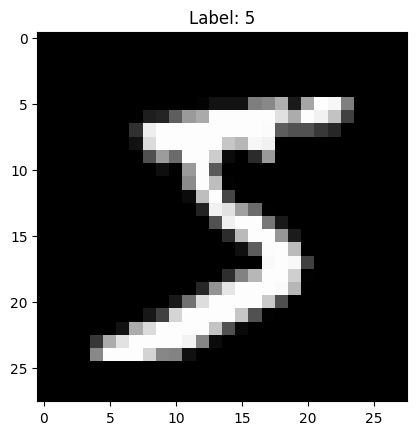

In [3]:
plt.imshow(x_train[0], cmap='gray')
plt.title(f"Label: {y_train[0]}")
plt.show()

Normalize Data

In [4]:
x_train = x_train / 255.0
x_test = x_test / 255.0

Reshape for CNN

In [5]:
x_train = x_train.reshape(-1, 28, 28, 1)
x_test = x_test.reshape(-1, 28, 28, 1)

print(x_train.shape)

(60000, 28, 28, 1)


Build CNN Model

In [6]:
model = models.Sequential()

# 1st Convolution Layer
model.add(layers.Conv2D(32, (3,3), activation='relu', input_shape=(28,28,1)))
model.add(layers.MaxPooling2D((2,2)))

# 2nd Convolution Layer
model.add(layers.Conv2D(64, (3,3), activation='relu'))
model.add(layers.MaxPooling2D((2,2)))

# Flatten
model.add(layers.Flatten())

# Fully Connected Layer
model.add(layers.Dense(128, activation='relu'))

# Output Layer
model.add(layers.Dense(10, activation='softmax'))

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Compile Model

In [7]:
model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

Train Model

In [8]:
history = model.fit(
    x_train, y_train,
    epochs=5,
    validation_split=0.1
)

Epoch 1/5
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 64s 37ms/step - accuracy: 0.9571 - loss: 0.1378 - val_accuracy: 0.9877 - val_loss: 0.0446
Epoch 2/5
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 59s 35ms/step - accuracy: 0.9862 - loss: 0.0428 - val_accuracy: 0.9877 - val_loss: 0.0381
Epoch 3/5
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 58s 35ms/step - accuracy: 0.9908 - loss: 0.0285 - val_accuracy: 0.9890 - val_loss: 0.0389
Epoch 4/5
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 62s 37ms/step - accuracy: 0.9929 - loss: 0.0212 - val_accuracy: 0.9890 - val_loss: 0.0384
Epoch 5/5
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 70s 42ms/step - accuracy: 0.9947 - loss: 0.0168 - val_accuracy: 0.9915 - val_loss: 0.0347


Evaluate Model

In [9]:
test_loss, test_acc = model.evaluate(x_test, y_test)

print("Test Accuracy:", test_acc)

313/313 ━━━━━━━━━━━━━━━━━━━━ 3s 10ms/step - accuracy: 0.9902 - loss: 0.0295
Test Accuracy: 0.9901999831199646


Plot Accuracy Graph

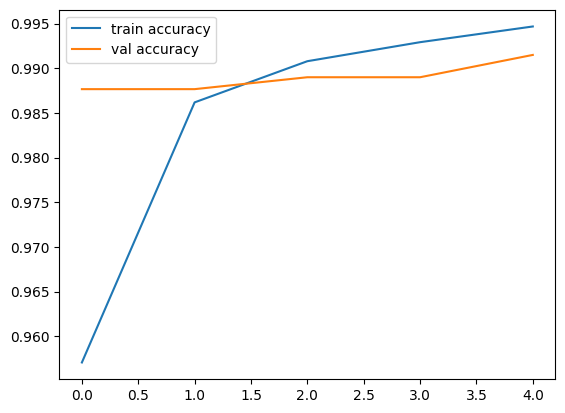

In [10]:
plt.plot(history.history['accuracy'], label='train accuracy')
plt.plot(history.history['val_accuracy'], label='val accuracy')
plt.legend()
plt.show()

Make Predictions

In [11]:
predictions = model.predict(x_test)

import numpy as np
print("Predicted:", np.argmax(predictions[0]))
print("Actual:", y_test[0])

313/313 ━━━━━━━━━━━━━━━━━━━━ 5s 14ms/step
Predicted: 7
Actual: 7
